
# K-Means with Incorrect K Values

## Objective
Understand the effect of choosing an incorrect number of clusters in K-Means.

## Dataset
`kmeans_wrongk.csv`

## Tasks
- Apply K-Means with:
  - K = 2
  - K = 3
  - K = 5
- Compare clustering results

## Questions
1. What happens when K is too small?
2. What happens when K is too large?
3. Which K best represents the data and why?


In [1]:

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Libraries imported successfully")


Libraries imported successfully


In [2]:

# Load dataset

data = pd.read_csv("kmeans_wrongk.csv")

print("First 5 rows of dataset:")
display(data.head())

print("\nDataset shape:", data.shape)


First 5 rows of dataset:


,Feature1,Feature2
0,-7.338988,-7.729954
1,-7.740041,-7.264665
2,-1.686653,7.793442
3,4.422198,3.071947
4,-8.917752,-7.888196



Dataset shape: (300, 2)


In [3]:

# Dataset information

print("Dataset Info:")
print(data.info())

print("\nStatistical Summary:")
display(data.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  300 non-null    float64
 1   Feature2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB
None

Statistical Summary:


,Feature1,Feature2
count,300.000000,300.000000
mean,-1.590000,1.356727
std,4.911284,6.641879
min,-9.351272,-9.182031
25%,-6.242487,-6.311418
50%,-2.544467,1.984582
75%,3.937954,8.295815
max,6.954537,11.734455



## Step 1: Select Numerical Features

K-Means works only with numerical values.  
Here we select numerical columns from the dataset.


In [4]:

# Select numerical columns

X = data.select_dtypes(include=[np.number]).copy()

print("Selected features:")
print(list(X.columns))

print("\nFeature matrix shape:", X.shape)
display(X.head())


Selected features:
['Feature1', 'Feature2']

Feature matrix shape: (300, 2)


,Feature1,Feature2
0,-7.338988,-7.729954
1,-7.740041,-7.264665
2,-1.686653,7.793442
3,4.422198,3.071947
4,-8.917752,-7.888196



## Step 2: Standardize the Features

K-Means is distance-based.  
Scaling helps each feature contribute fairly to the distance calculation.


In [5]:

# Standardize features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully")


Data standardized successfully



## Step 3: Apply K-Means with K = 2, K = 3, and K = 5


In [6]:

# Function to apply K-Means

def run_kmeans(X_input, k):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_input)
    return model, labels

# Run K-Means for different K values
k_values = [2, 3, 5]

models = {}
labels_dict = {}
inertia_dict = {}

for k in k_values:
    model, labels = run_kmeans(X_scaled, k)
    models[k] = model
    labels_dict[k] = labels
    inertia_dict[k] = model.inertia_
    data[f"Cluster_K_{k}"] = labels

print("K-Means completed for K = 2, 3, and 5")

print("\nInertia values:")
for k, inertia in inertia_dict.items():
    print(f"K = {k}: Inertia = {inertia}")


K-Means completed for K = 2, 3, and 5

Inertia values:
K = 2: Inertia = 187.79991946175915
K = 3: Inertia = 18.263159330895952
K = 5: Inertia = 12.715907526929659


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [7]:

# Compare cluster counts

cluster_counts = {}

for k in k_values:
    cluster_counts[f"K_{k}"] = pd.Series(labels_dict[k]).value_counts().sort_index()

cluster_counts_df = pd.DataFrame(cluster_counts)

print("Cluster counts for each K:")
display(cluster_counts_df)


Cluster counts for each K:


,K_2,K_3,K_5
0,200.0,100.0,40
1,100.0,100.0,45
2,NaN,100.0,100
3,NaN,NaN,60
4,NaN,NaN,55



## Step 4: Visualize the Data

If the dataset has more than two features, PCA is used to reduce it to 2D for visualization.


In [8]:

# Convert data to 2D for visualization

if X_scaled.shape[1] > 2:
    pca = PCA(n_components=2)
    X_plot = pca.fit_transform(X_scaled)
    x_label = "Principal Component 1"
    y_label = "Principal Component 2"

    print("PCA applied for visualization")
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Total variance explained:", pca.explained_variance_ratio_.sum())
else:
    X_plot = X_scaled
    x_label = X.columns[0]
    y_label = X.columns[1]

print("Plot data shape:", X_plot.shape)


Plot data shape: (300, 2)


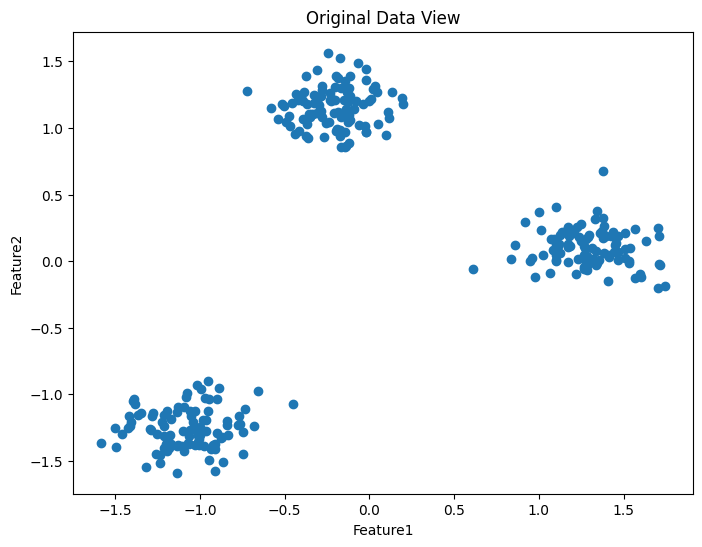

In [9]:

# Plot original data

plt.figure(figsize=(8, 6))

plt.scatter(
    X_plot[:, 0],
    X_plot[:, 1]
)

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title("Original Data View")

plt.show()



## Step 5: Plot Clusters for Each K


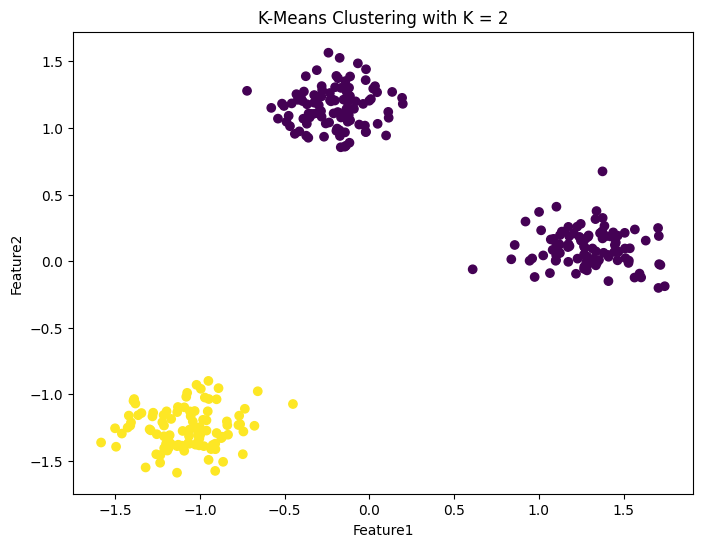

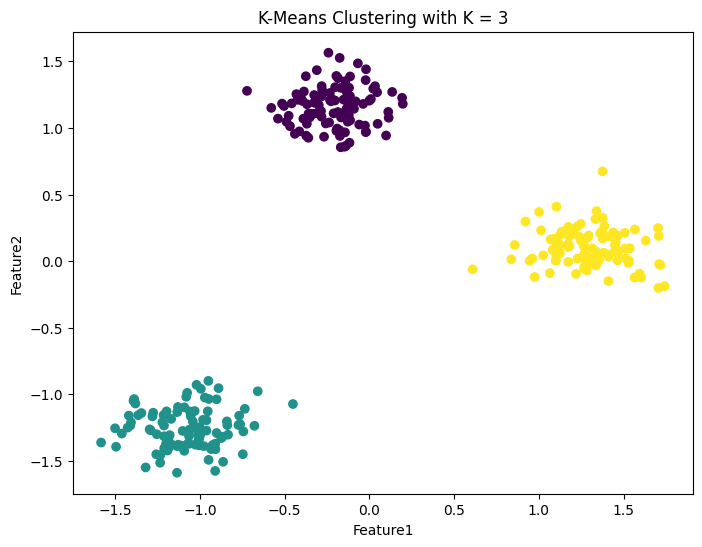

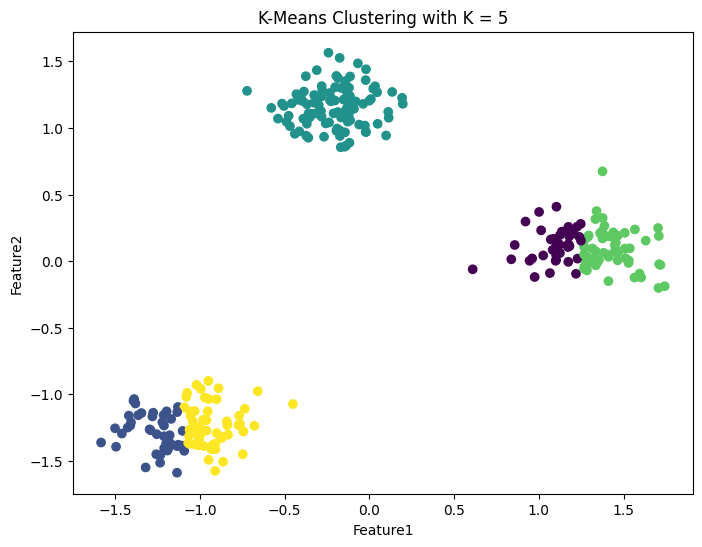

In [10]:

# Plot clusters for K = 2, 3, and 5

for k in k_values:
    plt.figure(figsize=(8, 6))

    plt.scatter(
        X_plot[:, 0],
        X_plot[:, 1],
        c=labels_dict[k]
    )

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f"K-Means Clustering with K = {k}")

    plt.show()



## Step 6: Compare Inertia Values

Inertia usually decreases as K increases.  
But lower inertia alone does not always mean better clustering.


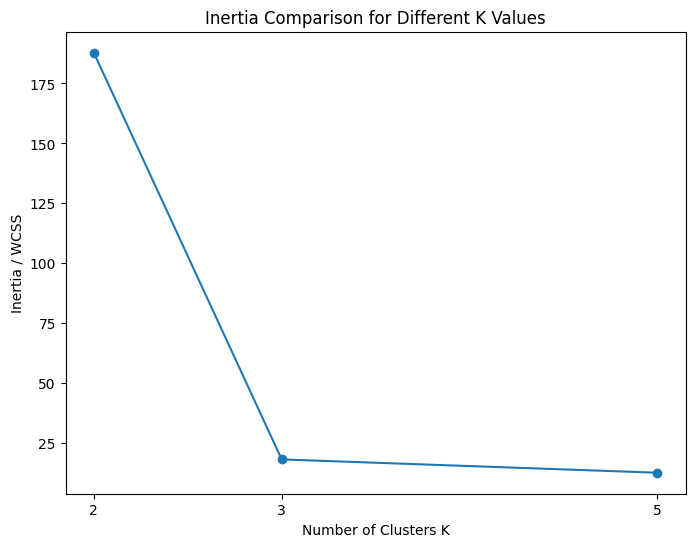

In [11]:

# Plot K vs Inertia

plt.figure(figsize=(8, 6))

plt.plot(
    list(inertia_dict.keys()),
    list(inertia_dict.values()),
    marker="o"
)

plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia / WCSS")
plt.title("Inertia Comparison for Different K Values")
plt.xticks(k_values)

plt.show()



## Step 7: Cluster Mean Comparison

Cluster means help understand how each K divides the dataset.


In [12]:

# Display cluster-wise means for each K in original feature scale

for k in k_values:
    print(f"\nCluster-wise feature means for K = {k}")
    display(data.groupby(f"Cluster_K_{k}")[X.columns].mean())



Cluster-wise feature means for K = 2


,Feature1,Feature2
Cluster_K_2,,
0,1.056935,5.527082
1,-6.883872,-6.983984



Cluster-wise feature means for K = 3


,Feature1,Feature2
Cluster_K_3,,
0,-2.633233,9.043570
1,-6.883872,-6.983984
2,4.747103,2.010594



Cluster-wise feature means for K = 5


,Feature1,Feature2
Cluster_K_5,,
0,3.757476,2.135189
1,-7.779534,-7.190326
2,-2.633233,9.043570
3,5.406855,1.927531
4,-6.151057,-6.815159



# Interpretation Guide

## When K is too small
If K is too small, different natural groups are forced into the same cluster.  
This is called **under-clustering**.

Example:
- If the data naturally has 3 groups but we choose K = 2,
  two groups may be merged incorrectly.

## When K is too large
If K is too large, one natural group may be split into smaller unnecessary clusters.  
This is called **over-clustering**.

Example:
- If the data naturally has 3 groups but we choose K = 5,
  one or more groups may be divided into artificial subgroups.

## Best K
The best K is the value that:
- Matches the visible natural grouping
- Has balanced and meaningful cluster separation
- Avoids unnecessary splitting or merging
- Makes sense based on domain understanding



# Answers to Questions

## 1. What happens when K is too small?

When K is too small, K-Means merges different natural groups into the same cluster.  
The model becomes too simple and cannot capture the real structure of the data.

This leads to:
- Poor separation
- Mixed clusters
- Loss of important patterns

---

## 2. What happens when K is too large?

When K is too large, K-Means splits natural clusters into smaller artificial clusters.  
The model becomes too detailed and may create clusters that do not have meaningful real-world interpretation.

This leads to:
- Over-clustering
- Unnecessary cluster divisions
- Harder interpretation

---

## 3. Which K best represents the data and why?

Usually, **K = 3** is expected to best represent this type of dataset if the data contains three natural groups.

Reason:
- K = 2 may merge two natural clusters.
- K = 5 may split natural clusters unnecessarily.
- K = 3 often balances separation and interpretability.

However, confirm this using:
- Cluster plots
- Inertia comparison
- Cluster-wise feature means
- Domain knowledge
